# Zeus ⚡ — Demo del agente generador de órdenes de trabajo

**Maestría en Automatización Industrial · UTH 2026.4** — Jayro Joel Rojas Avelar
Proyecto final · **Variante 3: generador de órdenes de trabajo (OT)**

Este notebook recorre **todo el pipeline de Zeus** de punta a punta, sin depender de la
red de Telegram (es el **plan B** de la demo en vivo). Cada paso corresponde a un
requisito de la rúbrica:

| Paso | Qué demuestra | Requisito |
|------|---------------|-----------|
| 1 | Clases POO (herencia + polimorfismo) | (1) |
| 2 | RAG sobre 2 manuales (WEG + ANSI/NETA) | (2) |
| 3 | Tool calling: detectar y pedir datos faltantes | (3) |
| 4 | Checklist de pruebas (el técnico reporta) | — |
| 5 | Salida 1: PDF profesional | (4) |
| 6 | Salida 2: correo SMTP | (4) |
| 7 | Ciclo de vida: ABIERTA → FINALIZADA | — |

> En la demo **en vivo**, todo esto entra y sale por **Telegram** (modo autónomo): el
> operador manda el reporte, Zeus razona y responde. Aquí lo corremos en local para
> verlo pieza por pieza, y como respaldo por si la red de Telegram falla.

## 0 · Configuración

Dos interruptores controlan la demo:

- **`MODO_ENSAYO`** — en `True` usa folios y almacén **temporales**, así podés correr el
  notebook las veces que quieras **sin gastar folios reales** ni ensuciar `data/ordenes.json`.
  Para la demo "de verdad" ponelo en `False` (emite el folio real y lo guarda).
- **`ENVIAR_CORREO`** — en `True` envía la OT por SMTP de verdad. Para la demo ponelo en `True`
  (que llegue el correo a la bandeja); para ensayar, dejalo en `False`.

In [1]:
import os, sys, json, tempfile
from IPython.display import display, HTML, Image

# ===================== INTERRUPTORES DE LA DEMO =====================
MODO_ENSAYO   = True     # True = folios/almacén temporales (no toca lo real). Demo real -> False
ENVIAR_CORREO = False    # True = envía el correo de verdad. Demo real -> True
# (Telegram no se usa aquí a propósito: este notebook es el plan B si la red de Telegram falla.)
# ===================================================================

# --- Localizar la raíz del proyecto (la carpeta que contiene 'src') y poner src/ en el path ---
raiz = os.getcwd()
while raiz and not os.path.isdir(os.path.join(raiz, "src")):
    padre = os.path.dirname(raiz)
    if padre == raiz:
        raise RuntimeError("No encontré la carpeta 'src'. Abrí el notebook dentro del proyecto.")
    raiz = padre
sys.path.insert(0, os.path.join(raiz, "src"))
print("Proyecto:", raiz)

# --- Módulos de Zeus (las 'tools' deterministas; el cerebro es la sesión de Claude) ---
import modelos, mensajes, rag, reporte, correo, almacen, folios, agente
from modelos import Equipo, OrdenTrabajoMotor, Prioridad

# --- En modo ensayo, redirigir folios y almacén a archivos temporales ---
if MODO_ENSAYO:
    demo_dir = os.path.join(tempfile.gettempdir(), "zeus_demo_ensayo")
    os.makedirs(demo_dir, exist_ok=True)
    folios._ARCHIVO  = os.path.join(demo_dir, "contador_ensayo.json")
    almacen._ARCHIVO = os.path.join(demo_dir, "ordenes_ensayo.json")
    json.dump({"2026": 8}, open(folios._ARCHIVO, "w"))   # arranca en 8 -> esta demo emite OT-2026-0009
    json.dump({}, open(almacen._ARCHIVO, "w"))
    print("MODO ENSAYO  -> folios y almacén temporales en:", demo_dir)
else:
    print("MODO REAL    -> usa folios y almacén de producción (gasta un folio).")

print("Último folio emitido:", folios.folio_actual(), " · el próximo será el de esta demo.")

Proyecto: C:\Users\Gessiel Rojas\Documents\Jayro\Automatizacion Industrial\progrmacion\AgenteUTH\zeus-agente-ot


MODO ENSAYO  -> folios y almacén temporales en: C:\Users\GESSIE~1\AppData\Local\Temp\zeus_demo_ensayo
Último folio emitido: OT-2026-0008  · el próximo será el de esta demo.


## 1 · Programación orientada a objetos (POO)

Zeus modela cada activo como un objeto **`Equipo`** y cada orden como una **subclase** de
**`OrdenDeTrabajo`**. La clase base define todo lo común; cada tipo de equipo (motor,
generador, transformador) **hereda** eso y aporta lo suyo por **polimorfismo**: su
checklist, su tipo de equipo y sus campos obligatorios.

Acá creamos la OT de un **motor** a partir de un reporte real de un operador.

In [2]:
# El operador reporta la falla en lenguaje natural (esto es lo que llegaría por Telegram):
reporte_operador = (
    "Buen día. El motor M-015 de la línea de envasado 2 está recalentando, "
    "huele a quemado y el guardamotor ya disparó dos veces hoy. Es un Siemens. Urge."
)

# Zeus razona el reporte y arma el Equipo. Deja en '(por confirmar)' lo que el operador NO dio:
motor = Equipo(
    tag="(por confirmar)",                  # el operador no dio el tag exacto
    nombre="Motor de línea de envasado 2",
    marca="Siemens",
    modelo="(por confirmar)",
    area="Empaque",
    criticidad="alta",
    clase_aislamiento="(por confirmar)",    # dato térmico clave del motor, aún sin confirmar
)

# La OT nace ABIERTA y toma un folio único y persistente:
ot = OrdenTrabajoMotor(
    equipo=motor,
    cliente="Industria Alimenticia Hondureña S.A.",
    planta="Planta de Producción SPS",
    ubicacion="Línea de Envasado 2",
    prioridad=Prioridad.ALTA,
)
ot.reporte_original = reporte_operador
ot.tipo = "correctivo"

# ----- Lo que demuestra la POO -----
print("Folio asignado            :", ot.folio)
print("Clase de la OT            :", type(ot).__name__)
print("¿Hereda de OrdenDeTrabajo? :", isinstance(ot, modelos.OrdenDeTrabajo))
print("tipo_equipo() [polimorf.] :", ot.tipo_equipo())
print("Pruebas del checklist     :", len(ot.checklist))
for p in ot.checklist:
    print("   -", p.nombre, (f"({p.unidad})" if p.unidad else ""))
print()
print(ot.resumen())
print("Equipo:", ot.equipo.descripcion())

Folio asignado            : OT-2026-0009
Clase de la OT            : OrdenTrabajoMotor
¿Hereda de OrdenDeTrabajo? : True
tipo_equipo() [polimorf.] : Motor
Pruebas del checklist     : 8
   - Inspección visual 
   - Medición de aislamiento (MΩ)
   - Resistencia de devanados (Ω)
   - Vibración (mm/s)
   - Temperatura (°C)
   - Alineación (mm)
   - Prueba en vacío (A)
   - Prueba con carga (A)

OT-2026-0009 · OT de Motor · (por confirmar) · prioridad alta · estado abierta
Equipo: [(por confirmar)] Motor de línea de envasado 2 Siemens (por confirmar) — área: Empaque


## 2 · RAG — conocimiento de los manuales

Zeus tiene una base de conocimiento ligera (por **palabras clave**, sin embeddings ni APIs)
con **2 manuales**: la *Guía de Especificación de Motores Eléctricos WEG* y el estándar
*ANSI/NETA ATS-2009*. El flujo es: **(1)** Zeus interpreta la falla, **(2)** con el equipo + la
falla recupera del manual los fragmentos pertinentes (**filtrados por tipo de equipo**) y
**(3)** los lee para redactar las acciones, los repuestos y el tiempo.

In [3]:
# (1) Zeus interpreta el reporte y resume la falla -- es su primer razonamiento:
ot.descripcion_falla = (
    "Sobrecalentamiento del motor con disparos repetidos del guardamotor. "
    "Posible sobrecarga térmica, falla de ventilación o aislamiento degradado."
)
print("Falla interpretada por Zeus:")
print("  ", ot.descripcion_falla)

Falla interpretada por Zeus:
   Sobrecalentamiento del motor con disparos repetidos del guardamotor. Posible sobrecarga térmica, falla de ventilación o aislamiento degradado.


In [4]:
# (2) Con el equipo + la falla, recupera del manual los fragmentos relevantes (filtrado por Motor):
print("Fragmentos en el RAG:", rag.contar())
for fuente, n in rag.fuentes().items():
    print(f"   · {fuente}: {n}")

contexto = agente.contexto_para(ot, k=4)
print("\n----- Contexto recuperado del manual (top-4, ordenado por relevancia) -----\n")
print(contexto[:1400] + ("..." if len(contexto) > 1400 else ""))

Fragmentos en el RAG: 295
   · WEG · Guía de Especificación de Motores Eléctricos: 268
   · ANSI/NETA ATS-2009 - Pruebas de aceptacion de equipo electrico: 27

----- Contexto recuperado del manual (top-4, ordenado por relevancia) -----

[WEG · Guía de Especificación de Motores Eléctricos] un buen aislamiento mecánico, térmico y eléctrico. El esmalte utilizado actualmente en los alambres garantiza esas propatasdades, siendo la propatasdad mecánica asegurada por la camada externa del esmalte que resiste a fuerzas de abrasión durante la inserción del mismo en las ranuras del estator. La camada de esmalte interna garantiza alta rigidez dieléctrica y el conjunto, atribuye clase 200 ºC al alambre ( UL File E234451 ). Ese alambre es utilizado en todos los motores clase B, F y H. En los motores para extracción de humo ( Smoke Extraction Motor ) el alambre es especial para altísimas temperaturas. Los films y laminados aislantes tienen la función de aislar térmica y eléctricamente partes de la b

**(3) Zeus lee ese contexto y redacta** las acciones recomendadas, los repuestos y el
tiempo estimado. (En vivo lo hace el modelo en la sesión; aquí queda escrito el resultado
de ese razonamiento, fundamentado en los fragmentos de arriba: protección térmica, clase
de aislamiento y ajuste del relé.)

In [5]:
ot.acciones_recomendadas = (
    "Verificar carga y corriente contra placa; ajustar el relé térmico a In×FS. "
    "Revisar ventilación y acumulación de polvo de empaque en la carcasa. "
    "Medir aislamiento y resistencia de devanados; controlar temperatura con Pt-100/PTC. "
    "Confirmar la clase de aislamiento (límite térmico) antes de reenergizar."
)
ot.descripcion_trabajo = (
    "Inspección térmica y eléctrica del motor; ajuste de la protección y limpieza de ventilación."
)
ot.repuestos_utilizados = ["Relé térmico (según In)", "Limpiador dieléctrico", "Sensor Pt-100 (si aplica)"]
ot.tiempo_estimado = "3.5 h"
ot.tecnico_asignado = "Ing. Jayro Rojas"
print("Acciones, repuestos y tiempo redactados por Zeus a partir del manual.  ✓")

Acciones, repuestos y tiempo redactados por Zeus a partir del manual.  ✓


## 3 · Tool calling — detectar y pedir los datos que faltan

Antes de poder cerrar la OT, Zeus comprueba qué **datos obligatorios** faltan (según el
tipo de equipo, vía `CAMPOS_OBLIGATORIOS`) y se los pide al operador. Es una de sus
herramientas deterministas.

In [6]:
faltan = mensajes.campos_faltantes(ot)
print("Campos obligatorios que faltan:", [etq for _c, etq in faltan])

print("\n----- Mensaje que Zeus le manda al operador -----")
display(HTML(mensajes.solicitar_datos(ot)))

# El operador responde (esto llegaría por Telegram). Zeus vuelca las respuestas a la OT:
respuesta_operador = "Tag: M-015\nModelo: 1LE1003\nClase de aislamiento: F"
aplicados = mensajes.aplicar_datos(ot, respuesta_operador)
print("Datos aplicados:", aplicados)
print("¿Faltan datos ahora? ->", mensajes.campos_faltantes(ot) or "no, la OT está completa ✓")

Campos obligatorios que faltan: ['Tag / identificador', 'Modelo', 'Clase de aislamiento (A/E/B/F/H)']

----- Mensaje que Zeus le manda al operador -----


Datos aplicados: ['tag', 'modelo', 'clase_aislamiento']
¿Faltan datos ahora? -> no, la OT está completa ✓


## 4 · Checklist de pruebas — el técnico reporta los resultados

En campo, el técnico registra cada prueba. Por Telegram lo hace con **`/pruebas`** (guiado,
una por una) o mandando `Prueba: valor | estado | observación`. Acá usamos el **mismo parser**
(`mensajes.aplicar_resultado`), tolerante a unidades y acentos. Incluimos un par de pruebas
**fuera de rango** para ver el coloreado del checklist.

In [7]:
resultados_campo = [
    "Inspección visual: carcasa con polvo de empaque | OK | se limpió",
    "Medición de aislamiento: 480 MΩ | OK | aceptable (> 100 MΩ)",
    "Resistencia de devanados: 0.43 Ω | OK | equilibrada entre fases",
    "Vibración: 2.4 mm/s | OK | dentro de ISO 10816",
    "Temperatura: 96 °C | fuera de rango | excede el límite de la Clase F en carga",
    "Alineación: 0.05 mm | OK |",
    "Prueba en vacío: 12.1 A | OK |",
    "Prueba con carga: 51 A | fuera de rango | supera la In de placa, revisar carga",
]
for linea in resultados_campo:
    nombre = mensajes.aplicar_resultado(ot, linea)
    print("registrada:", nombre)

print("\n----- Checklist de la OT -----")
for p in ot.checklist:
    print("  ", p)

registrada: Inspección visual
registrada: Medición de aislamiento
registrada: Resistencia de devanados
registrada: Vibración
registrada: Temperatura
registrada: Alineación
registrada: Prueba en vacío
registrada: Prueba con carga

----- Checklist de la OT -----
   [x] Inspección visual: carcasa con polvo de empaque (OK) · se limpió
   [x] Medición de aislamiento: 480 MΩ (OK) · aceptable (> 100 MΩ)
   [x] Resistencia de devanados: 0.43 Ω (OK) · equilibrada entre fases
   [x] Vibración: 2.4 mm/s (OK) · dentro de ISO 10816
   [x] Temperatura: 96 °C (fuera de rango) · excede el límite de la Clase F en carga
   [x] Alineación: 0.05 mm (OK)
   [x] Prueba en vacío: 12.1 A (OK)
   [x] Prueba con carga: 51 A (fuera de rango) · supera la In de placa, revisar carga


## 5 · Salida 1 — PDF profesional de la OT

Zeus arma el PDF **directamente desde el objeto OT** (con `fpdf2`), con el diseño
corporativo: encabezado, badges de prioridad/estado, datos, checklist coloreado y firmas.
Lo renderizamos acá dentro para verlo.

PDF generado: C:\Users\Gessiel Rojas\Documents\Jayro\Automatizacion Industrial\progrmacion\AgenteUTH\zeus-agente-ot\salida\OT-2026-0009.pdf


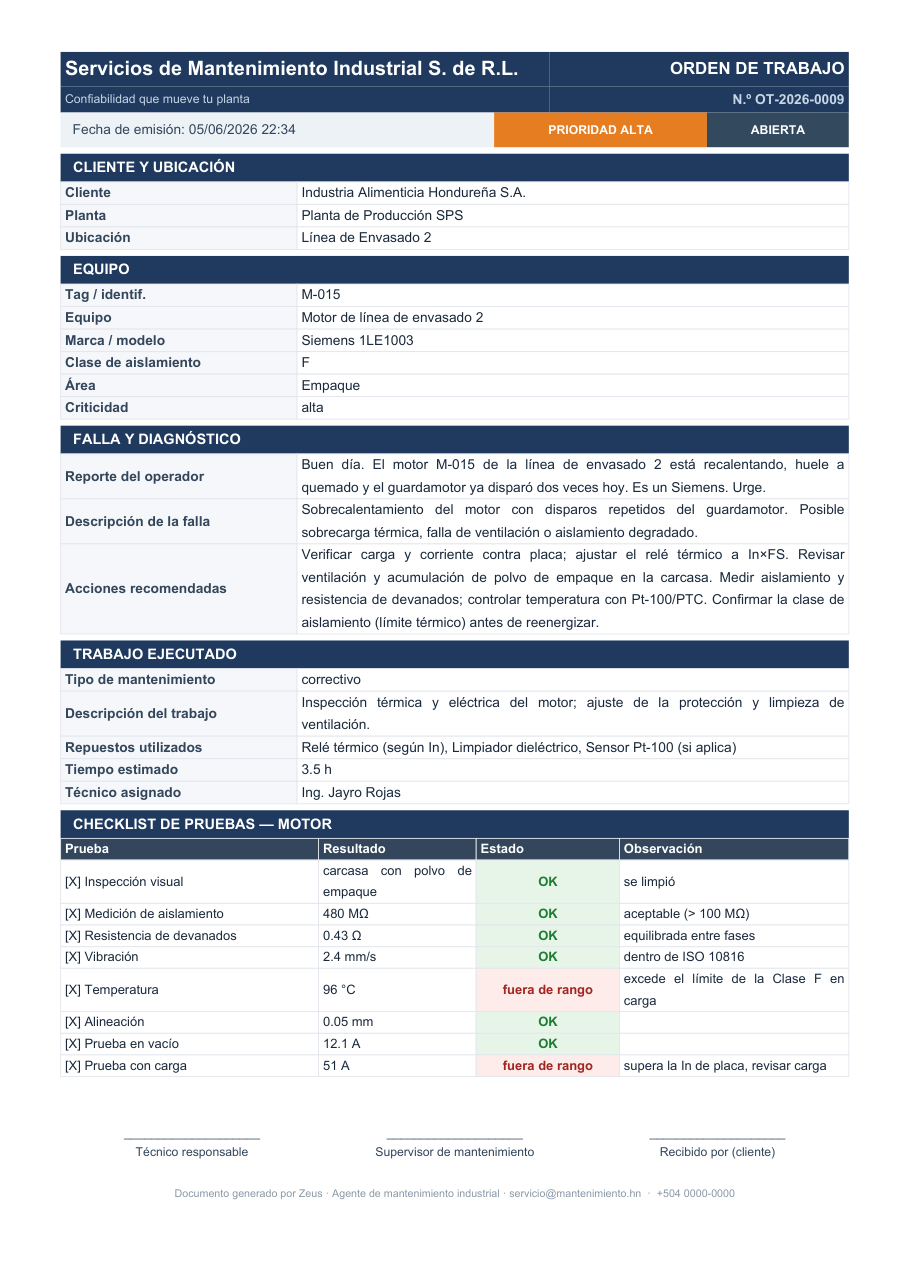

In [8]:
import fitz   # PyMuPDF: render del PDF a imagen para mostrarlo en el notebook

salida_dir = os.path.join(raiz, "salida")
os.makedirs(salida_dir, exist_ok=True)
ruta_pdf = reporte.generar_pdf(ot, os.path.join(salida_dir, f"{ot.folio}.pdf"))
print("PDF generado:", ruta_pdf)

doc = fitz.open(ruta_pdf)
for i, pagina in enumerate(doc):
    pix = pagina.get_pixmap(dpi=110)
    png = os.path.join(tempfile.gettempdir(), f"_demo_{ot.folio}_p{i+1}.png")
    pix.save(png)
    display(Image(filename=png))
doc.close()

## 6 · Salida 2 — correo SMTP

La misma OT se envía por correo: el **cuerpo** es un cuadro-resumen profesional (estilos
inline, compatible con Gmail/Outlook) y el **PDF va adjunto**. Primero la vista previa del
cuerpo; luego el envío real (si `ENVIAR_CORREO=True`).

In [9]:
# Vista previa del cuerpo del correo (el cuadro profesional que ve el responsable):
display(HTML(reporte.cuerpo_correo(ot, "ABIERTA")))

# Envío real (solo si ENVIAR_CORREO=True y hay credenciales en .env):
if ENVIAR_CORREO and correo.envio_configurado():
    destino = correo.enviar_ot(
        ruta_pdf,
        asunto=f"[{ot.cliente}] Orden de trabajo {ot.folio} - ABIERTA",
        cuerpo_html=reporte.cuerpo_correo(ot, "ABIERTA"),
        cuerpo_texto=f"Orden de trabajo {ot.folio} ({ot.cliente}). Se adjunta el PDF.",
    )
    print("✅ Correo enviado a:", destino)
elif ENVIAR_CORREO:
    print("⚠️ ENVIAR_CORREO=True pero faltan credenciales en .env (ZEUS_EMAIL / ZEUS_APP_PASSWORD).")
else:
    print("ℹ️ ENVIAR_CORREO=False (ensayo): no se envió. En la demo real ponelo en True.")

ℹ️ ENVIAR_CORREO=False (ensayo): no se envió. En la demo real ponelo en True.


## 7 · Ciclo de vida — finalizar la OT

Cuando el operador dice **«terminada»**, Zeus comprueba que no falten datos obligatorios,
marca la OT como **FINALIZADA** y regenera el PDF final (ahora con el **badge verde** de
finalizada). El folio es único y persistente: sobrevive al cierre del programa.

Estado de la OT: FINALIZADA · cerrada el 05/06/2026 22:34


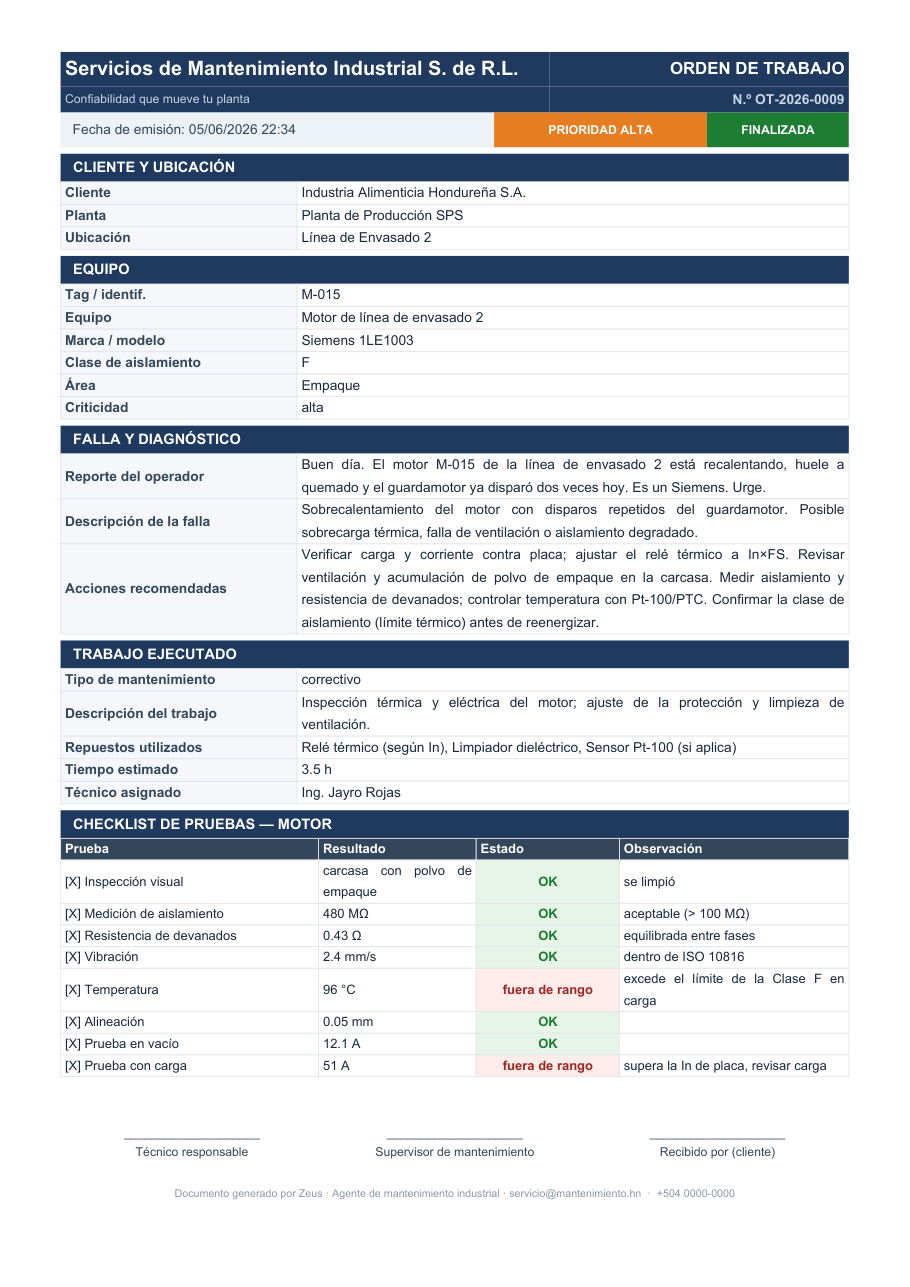

In [10]:
# El almacén persiste la OT (igual que en producción), y la finalizamos:
almacen.guardar(ot)
ot.finalizar("Trabajo correctivo concluido; motor operativo dentro de parámetros.")
almacen.guardar(ot)
print("Estado de la OT:", ot.estado.value.upper(), "· cerrada el", ot.fecha_cierre.strftime("%d/%m/%Y %H:%M"))

# PDF final con el badge verde de FINALIZADA:
ruta_final = reporte.generar_pdf(ot, os.path.join(salida_dir, f"{ot.folio}.pdf"))
doc = fitz.open(ruta_final)
pix = doc[0].get_pixmap(dpi=110)
png = os.path.join(tempfile.gettempdir(), f"_demo_final_{ot.folio}.png")
pix.save(png); doc.close()
display(Image(filename=png))

## ✓ Resumen

En este notebook Zeus llevó un **reporte en lenguaje natural** hasta una **orden de trabajo
profesional, finalizada y enviada**, demostrando:

- **POO** — `OrdenTrabajoMotor` hereda de `OrdenDeTrabajo` y define su checklist por polimorfismo.
- **RAG** — recuperó contexto de 2 manuales (WEG + ANSI/NETA) para el diagnóstico y las acciones.
- **Tool calling** — detectó y pidió los datos faltantes; registró el checklist con su parser.
- **Salida doble** — PDF profesional **+** correo SMTP con el PDF adjunto.
- **Ciclo de vida** — ABIERTA → FINALIZADA, con folio único y persistente.

> En la **demo en vivo**, este mismo flujo ocurre por **Telegram**, con Zeus razonando cada
> reporte de forma autónoma. Este notebook es el **plan B**: corre igual aunque la red de
> Telegram falle.